In [10]:
"""
Modelos de dados usando Pydantic para validação e estruturação.
"""

from pydantic import BaseModel, Field, validator
from typing import Optional, List, Dict
from datetime import datetime


class DataLoaderConfig(BaseModel):
    """
    Configuração para carregamento de dados com validação automática.

    Attributes:
        url: URL do arquivo JSON
        chave: Chave principal no JSON
        coluna_valor: Nome da coluna com valores monetários
        prefixos_remover: Lista de prefixos a serem removidos dos valores
    """
    url: str = Field(..., description="URL do arquivo JSON")
    chave: str = Field(..., min_length=1, description="Chave principal do JSON")
    coluna_valor: str = Field(..., min_length=1, description="Coluna com valores monetários")
    prefixos_remover: Optional[List[str]] = Field(default_factory=list, description="Prefixos para remover")

    @validator('url')
    def validar_url(cls, v):
        if not (v.startswith('http://') or v.startswith('https://')):
            raise ValueError('URL deve começar com http:// ou https://')
        return v

    class Config:
        extra = "allow"
        schema_extra = {
            "example": {
                "url": "https://exemplo.com/dados.json",
                "chave": "dados_vendas",
                "coluna_valor": "Valor da compra",
                "prefixos_remover": ["R$ "]
            }
        }


class VendaModel(BaseModel):
    """
    Modelo para representar uma venda individual.

    Attributes:
        cliente: Nome do cliente (automaticamente limpo)
        valor_compra: Valor da compra (deve ser positivo)
        data_venda: Data da venda
    """
    cliente: str = Field(..., min_length=1, description="Nome do cliente")
    valor_compra: float = Field(..., gt=0, description="Valor da compra")
    data_venda: datetime = Field(..., description="Data da venda")

    @validator('cliente')
    def limpar_nome_cliente(cls, v):
        """Remove caracteres especiais e padroniza o nome"""
        import re
        nome_limpo = re.sub(r'[^a-zA-Z\s]', '', v.lower().strip())
        nome_limpo = re.sub(r'\s+', ' ', nome_limpo)
        return nome_limpo

    @validator('valor_compra')
    def validar_valor_positivo(cls, v):
        """Garante que o valor seja positivo"""
        if v <= 0:
            raise ValueError('Valor da compra deve ser positivo')
        return round(v, 2)

    class Config:
        schema_extra = {
            "example": {
                "cliente": "João Silva",
                "valor_compra": 150.50,
                "data_venda": "2024-01-15T10:30:00"
            }
        }


class LocacaoModel(BaseModel):
    """
    Modelo para representar dados de locação.

    Attributes:
        apartamento: Número/identificação do apartamento
        valor_aluguel: Valor do aluguel
        data_combinada_pagamento: Data acordada para pagamento
        data_pagamento: Data efetiva do pagamento
    """
    apartamento: str = Field(..., min_length=1, description="Identificação do apartamento")
    valor_aluguel: float = Field(..., gt=0, description="Valor do aluguel")
    data_combinada_pagamento: datetime = Field(..., description="Data acordada para pagamento")
    data_pagamento: datetime = Field(..., description="Data efetiva do pagamento")

    @validator('apartamento')
    def limpar_apartamento(cls, v):
        """Remove padrões desnecessários do número do apartamento"""
        return v.replace('(blocoAP)', '').replace('bloco', '').strip()

    @validator('valor_aluguel')
    def validar_aluguel(cls, v):
        """Valida valor do aluguel"""
        if v <= 0:
            raise ValueError('Valor do aluguel deve ser positivo')
        return round(v, 2)

    @property
    def atraso_dias(self) -> int:
        """Calcula atraso em dias (propriedade computada)"""
        return (self.data_pagamento - self.data_combinada_pagamento).days

    @property
    def status_pagamento(self) -> str:
        """Determina status do pagamento baseado no atraso"""
        atraso = self.atraso_dias
        if atraso <= 0:
            return "Pontual"
        elif atraso <= 5:
            return "Atraso Leve"
        elif atraso <= 15:
            return "Atraso Moderado"
        else:
            return "Atraso Severo"

    class Config:
        schema_extra = {
            "example": {
                "apartamento": "101A",
                "valor_aluguel": 1200.00,
                "data_combinada_pagamento": "2024-01-05T00:00:00",
                "data_pagamento": "2024-01-08T00:00:00"
            }
        }


class EstatisticasBase(BaseModel):
    """Classe base para estatísticas comuns"""
    total_registros: int = Field(..., ge=0, description="Total de registros")
    data_inicio: datetime = Field(..., description="Data inicial dos dados")
    data_fim: datetime = Field(..., description="Data final dos dados")

    @property
    def duracao_dias(self) -> int:
        """Calcula duração em dias"""
        return (self.data_fim - self.data_inicio).days + 1


class RelatorioVendas(EstatisticasBase):
    """
    Relatório estruturado de análise de vendas.
    """
    cliente_vencedor: str = Field(..., description="Cliente com maior compra")
    valor_vencedor: float = Field(..., gt=0, description="Valor da maior compra")
    total_clientes: int = Field(..., ge=1, description="Total de clientes únicos")
    valor_total_evento: float = Field(..., gt=0, description="Valor total do evento")
    valor_medio_por_cliente: float = Field(..., gt=0, description="Ticket médio por cliente")
    valor_mediano_por_cliente: float = Field(..., gt=0, description="Valor mediano por cliente")
    top_5_clientes: Dict[str, float] = Field(..., description="Top 5 clientes por valor")

    @validator('top_5_clientes')
    def validar_top_5(cls, v):
        """Valida se o top 5 tem no máximo 5 itens"""
        if len(v) > 5:
            raise ValueError('Top 5 não pode ter mais de 5 clientes')
        return v

    @property
    def participacao_vencedor_percentual(self) -> float:
        """Percentual de participação do cliente vencedor"""
        return (self.valor_vencedor / self.valor_total_evento) * 100

    @property
    def concentracao_top_5_percentual(self) -> float:
        """Percentual de concentração dos top 5 clientes"""
        total_top_5 = sum(self.top_5_clientes.values())
        return (total_top_5 / self.valor_total_evento) * 100

    class Config:
        schema_extra = {
            "example": {
                "cliente_vencedor": "maria silva",
                "valor_vencedor": 2500.00,
                "total_clientes": 45,
                "valor_total_evento": 15000.00,
                "valor_medio_por_cliente": 333.33,
                "valor_mediano_por_cliente": 200.00,
                "top_5_clientes": {
                    "maria silva": 2500.00,
                    "joao santos": 1800.00,
                    "ana costa": 1200.00,
                    "carlos oliveira": 950.00,
                    "lucia ferreira": 800.00
                }
            }
        }


class RelatorioAlugueis(EstatisticasBase):
    """
    Relatório estruturado de análise de aluguéis.
    """
    apartamento_mais_atrasado: str = Field(..., description="Apartamento com maior atraso")
    atraso_maximo_medio: float = Field(..., description="Maior atraso médio em dias")
    apartamento_mais_pontual: str = Field(..., description="Apartamento mais pontual")
    atraso_minimo_medio: float = Field(..., description="Menor atraso médio em dias")
    total_apartamentos: int = Field(..., ge=1, description="Total de apartamentos")
    atraso_medio_geral: float = Field(..., description="Atraso médio geral em dias")
    atraso_mediano_geral: float = Field(..., description="Atraso mediano geral em dias")
    distribuicao_pontualidade: Dict[str, int] = Field(..., description="Distribuição por categoria")
    ranking_atrasos: Dict[str, float] = Field(..., description="Ranking de atrasos por apartamento")

    @validator('distribuicao_pontualidade')
    def validar_distribuicao(cls, v):
        """Valida se a distribuição tem as categorias corretas"""
        categorias_esperadas = {'pontuais', 'atraso_leve', 'atraso_moderado', 'atraso_severo'}
        if not categorias_esperadas.issubset(v.keys()):
            raise ValueError(f'Distribuição deve conter: {categorias_esperadas}')
        return v

    @property
    def percentual_pontuais(self) -> float:
        """Percentual de apartamentos pontuais"""
        return (self.distribuicao_pontualidade['pontuais'] / self.total_apartamentos) * 100

    @property
    def percentual_problematicos(self) -> float:
        """Percentual de apartamentos com atraso severo"""
        return (self.distribuicao_pontualidade['atraso_severo'] / self.total_apartamentos) * 100

    @property
    def nivel_risco_financeiro(self) -> str:
        """Avalia nível de risco financeiro do condomínio"""
        perc_problematicos = self.percentual_problematicos
        if perc_problematicos > 30:
            return "CRÍTICO"
        elif perc_problematicos > 15:
            return "ALTO"
        elif perc_problematicos > 5:
            return "MODERADO"
        else:
            return "BAIXO"

    class Config:
        schema_extra = {
            "example": {
                "apartamento_mais_atrasado": "304B",
                "atraso_maximo_medio": 25.5,
                "apartamento_mais_pontual": "102A",
                "atraso_minimo_medio": -2.1,
                "total_apartamentos": 50,
                "atraso_medio_geral": 8.3,
                "atraso_mediano_geral": 5.0,
                "distribuicao_pontualidade": {
                    "pontuais": 15,
                    "atraso_leve": 20,
                    "atraso_moderado": 12,
                    "atraso_severo": 3
                },
                "ranking_atrasos": {
                    "304B": 25.5,
                    "205C": 18.2,
                    "401A": 15.8
                }
            }
        }


class ConfiguracaoProjeto(BaseModel):
    """
    Configuração geral do projeto com validação.
    """
    nome_projeto: str = Field(..., min_length=1, description="Nome do projeto")
    versao: str = Field(default="1.0.0", description="Versão do projeto")
    autor: str = Field(..., min_length=1, description="Autor do projeto")
    descricao: Optional[str] = Field(None, description="Descrição do projeto")
    configuracoes_vendas: DataLoaderConfig = Field(..., description="Config dados de vendas")
    configuracoes_locacao: DataLoaderConfig = Field(..., description="Config dados de locação")

    class Config:
        schema_extra = {
            "example": {
                "nome_projeto": "Análise de Vendas e Aluguéis",
                "versao": "2.0.0",
                "autor": "Equipe Analytics",
                "descricao": "Sistema modular para análise de dados comerciais",
                "configuracoes_vendas": {
                    "url": "https://api.exemplo.com/vendas.json",
                    "chave": "dados_vendas",
                    "coluna_valor": "Valor da compra",
                    "prefixos_remover": ["R$ "]
                },
                "configuracoes_locacao": {
                    "url": "https://api.exemplo.com/locacao.json",
                    "chave": "dados_locacao",
                    "coluna_valor": "valor_aluguel",
                    "prefixos_remover": ["$", " reais"]
                }
            }
        }

/tmp/ipython-input-632369787.py:25: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator('url')
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_config.py:373: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)
/tmp/ipython-input-632369787.py:56: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator('cliente')
/tmp/ip

In [ ]:
# data_loader.py - Classe para carregamento de dados
import pandas as pd
import numpy as np
from typing import List
import re


class DataLoader:
    """Carregador de dados otimizado com validação Pydantic"""

    def __init__(self):
        self.cache = {}

    def carregar_dados(self, config: DataLoaderConfig) -> pd.DataFrame:
        """Carrega dados usando configuração validada"""
        try:
            # Verifica cache
            if config.url in self.cache:
                return self.cache[config.url].copy()

            # Carrega dados do JSON
            dados_json = pd.read_json(config.url)

            if config.chave not in dados_json:
                raise ValueError(f"Chave '{config.chave}' não encontrada no JSON")

            # Normaliza e processa dados
            dados = pd.json_normalize(dados_json[config.chave])
            dados = self._explodir_colunas_lista(dados)
            dados = self._limpar_valores_monetarios(dados, config.coluna_valor, config.prefixos_remover)

            # Cache dos dados
            self.cache[config.url] = dados.copy()

            return dados

        except Exception as e:
            raise RuntimeError(f"Erro ao carregar dados: {str(e)}")

    def _explodir_colunas_lista(self, df: pd.DataFrame) -> pd.DataFrame:
        """Explode colunas que contêm listas"""
        colunas_para_explodir = df.columns[1:].tolist()
        if colunas_para_explodir:
            return df.explode(colunas_para_explodir).reset_index(drop=True)
        return df

    def _limpar_valores_monetarios(self, df: pd.DataFrame, coluna: str, prefixos: List[str]) -> pd.DataFrame:
        """Limpa e converte valores monetários"""
        if coluna not in df.columns:
            raise KeyError(f"Coluna '{coluna}' não encontrada")

        # Remove prefixos
        for prefixo in prefixos:
            df[coluna] = df[coluna].str.replace(prefixo, '', regex=False)

        # Padroniza formato
        df[coluna] = (df[coluna]
                     .str.replace(',', '.', regex=False)
                     .str.strip())

        # Converte para float
        df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

        return df

    @staticmethod
    def processar_datas(df: pd.DataFrame, colunas_data: List[str]) -> pd.DataFrame:
        """Converte colunas para datetime"""
        df_copy = df.copy()
        for coluna in colunas_data:
            if coluna in df_copy.columns:
                df_copy[coluna] = pd.to_datetime(df_copy[coluna], errors='coerce')
        return df_copy


# analytics.py - Classes de análise
import pandas as pd
from typing import Tuple, Dict


class AnalisadorVendas:
    """Analisador de dados de vendas com Pydantic"""

    def __init__(self, dados_vendas: pd.DataFrame):
        self.dados_vendas = dados_vendas

    def calcular_total_por_cliente(self) -> pd.Series:
        """Calcula total de compras por cliente"""
        return (self.dados_vendas
                .groupby('Cliente')['Valor da compra']
                .sum()
                .sort_values(ascending=False))

    def identificar_cliente_vencedor(self) -> Tuple[str, float]:
        """Identifica cliente com maior compra"""
        total_compras = self.calcular_total_por_cliente()
        return total_compras.index[0], total_compras.iloc[0]

    def gerar_relatorio(self) -> RelatorioVendas:
        """Gera relatório estruturado com Pydantic"""
        total_compras = self.calcular_total_por_cliente()
        cliente_vencedor, valor_vencedor = self.identificar_cliente_vencedor()

        return RelatorioVendas(
            cliente_vencedor=cliente_vencedor,
            valor_vencedor=valor_vencedor,
            total_clientes=len(total_compras),
            valor_total_evento=total_compras.sum(),
            valor_medio_por_cliente=total_compras.mean(),
            duracao_evento_dias=(self.dados_vendas['Data de venda'].max() -
                               self.dados_vendas['Data de venda'].min()).days + 1,
            top_5_clientes=total_compras.head(5).to_dict(),
            data_inicio=self.dados_vendas['Data de venda'].min(),
            data_fim=self.dados_vendas['Data de venda'].max()
        )


class AnalisadorAluguel:
    """Analisador de dados de aluguel com Pydantic"""

    def __init__(self, dados_locacao: pd.DataFrame):
        self.dados_locacao = dados_locacao

    def calcular_atrasos(self) -> pd.DataFrame:
        """Calcula atrasos nos pagamentos"""
        df_copy = self.dados_locacao.copy()
        df_copy['atraso'] = (df_copy['datas_de_pagamento'] -
                            df_copy['datas_combinadas_pagamento']).dt.days
        return df_copy

    def calcular_media_atraso_por_apartamento(self) -> pd.Series:
        """Calcula média de atraso por apartamento"""
        dados_com_atraso = self.calcular_atrasos()
        return (dados_com_atraso
                .groupby('apartamento')['atraso']
                .mean()
                .sort_values(ascending=False))

    def classificar_apartamentos(self) -> Dict[str, List[str]]:
        """Classifica apartamentos por pontualidade"""
        media_atraso = self.calcular_media_atraso_por_apartamento()

        return {
            'pontuais': media_atraso[media_atraso <= 0].index.tolist(),
            'atraso_leve': media_atraso[(media_atraso > 0) & (media_atraso <= 5)].index.tolist(),
            'atraso_moderado': media_atraso[(media_atraso > 5) & (media_atraso <= 15)].index.tolist(),
            'atraso_severo': media_atraso[media_atraso > 15].index.tolist()
        }

    def gerar_relatorio(self) -> RelatorioAlugueis:
        """Gera relatório estruturado com Pydantic"""
        media_atraso = self.calcular_media_atraso_por_apartamento()
        distribuicao = self.classificar_apartamentos()

        return RelatorioAlugueis(
            apartamento_mais_atrasado=media_atraso.index[0],
            atraso_maximo_medio=media_atraso.iloc[0],
            apartamento_mais_pontual=media_atraso.index[-1],
            atraso_minimo_medio=media_atraso.iloc[-1],
            total_apartamentos=len(media_atraso),
            atraso_medio_geral=self.calcular_atrasos()['atraso'].mean(),
            distribuicao_pontualidade={k: len(v) for k, v in distribuicao.items()},
            ranking_atrasos=media_atraso.head(10).to_dict()
        )



In [ ]:
# analytics.py - Classes de análise
import pandas as pd
from typing import Tuple, Dict


class AnalisadorVendas:
    """Analisador de dados de vendas com Pydantic"""

    def __init__(self, dados_vendas: pd.DataFrame):
        self.dados_vendas = dados_vendas

    def calcular_total_por_cliente(self) -> pd.Series:
        """Calcula total de compras por cliente"""
        return (self.dados_vendas
                .groupby('Cliente')['Valor da compra']
                .sum()
                .sort_values(ascending=False))

    def identificar_cliente_vencedor(self) -> Tuple[str, float]:
        """Identifica cliente com maior compra"""
        total_compras = self.calcular_total_por_cliente()
        return total_compras.index[0], total_compras.iloc[0]

    def gerar_relatorio(self) -> RelatorioVendas:
        """Gera relatório estruturado com Pydantic"""
        total_compras = self.calcular_total_por_cliente()
        cliente_vencedor, valor_vencedor = self.identificar_cliente_vencedor()

        return RelatorioVendas(
            cliente_vencedor=cliente_vencedor,
            valor_vencedor=valor_vencedor,
            total_clientes=len(total_compras),
            valor_total_evento=total_compras.sum(),
            valor_medio_por_cliente=total_compras.mean(),
            duracao_evento_dias=(self.dados_vendas['Data de venda'].max() -
                               self.dados_vendas['Data de venda'].min()).days + 1,
            top_5_clientes=total_compras.head(5).to_dict(),
            data_inicio=self.dados_vendas['Data de venda'].min(),
            data_fim=self.dados_vendas['Data de venda'].max()
        )


class AnalisadorAluguel:
    """Analisador de dados de aluguel com Pydantic"""

    def __init__(self, dados_locacao: pd.DataFrame):
        self.dados_locacao = dados_locacao

    def calcular_atrasos(self) -> pd.DataFrame:
        """Calcula atrasos nos pagamentos"""
        df_copy = self.dados_locacao.copy()
        df_copy['atraso'] = (df_copy['datas_de_pagamento'] -
                            df_copy['datas_combinadas_pagamento']).dt.days
        return df_copy

    def calcular_media_atraso_por_apartamento(self) -> pd.Series:
        """Calcula média de atraso por apartamento"""
        dados_com_atraso = self.calcular_atrasos()
        return (dados_com_atraso
                .groupby('apartamento')['atraso']
                .mean()
                .sort_values(ascending=False))

    def classificar_apartamentos(self) -> Dict[str, List[str]]:
        """Classifica apartamentos por pontualidade"""
        media_atraso = self.calcular_media_atraso_por_apartamento()

        return {
            'pontuais': media_atraso[media_atraso <= 0].index.tolist(),
            'atraso_leve': media_atraso[(media_atraso > 0) & (media_atraso <= 5)].index.tolist(),
            'atraso_moderado': media_atraso[(media_atraso > 5) & (media_atraso <= 15)].index.tolist(),
            'atraso_severo': media_atraso[media_atraso > 15].index.tolist()
        }

    def gerar_relatorio(self) -> RelatorioAlugueis:
        """Gera relatório estruturado com Pydantic"""
        media_atraso = self.calcular_media_atraso_por_apartamento()
        distribuicao = self.classificar_apartamentos()

        return RelatorioAlugueis(
            apartamento_mais_atrasado=media_atraso.index[0],
            atraso_maximo_medio=media_atraso.iloc[0],
            apartamento_mais_pontual=media_atraso.index[-1],
            atraso_minimo_medio=media_atraso.iloc[-1],
            total_apartamentos=len(media_atraso),
            atraso_medio_geral=self.calcular_atrasos()['atraso'].mean(),
            distribuicao_pontualidade={k: len(v) for k, v in distribuicao.items()},
            ranking_atrasos=media_atraso.head(10).to_dict()
        )


In [ ]:
# visualizations.py - Visualizações com Matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional
import pandas as pd


class VisualizadorVendas:
    """Visualizações para análise de vendas"""

    def __init__(self, relatorio: RelatorioVendas, dados: pd.DataFrame):
        self.relatorio = relatorio
        self.dados = dados
        plt.style.use('seaborn-v0_8')
        sns.set_palette("husl")

    def plot_top_clientes(self, top_n: int = 10, figsize: tuple = (12, 8)) -> None:
        """Gráfico dos top clientes"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # Gráfico de barras horizontais
        top_clientes = pd.Series(self.relatorio.top_5_clientes)
        top_clientes.plot(kind='barh', ax=ax1, color='skyblue')
        ax1.set_title('Top 5 Clientes por Valor de Compra', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Valor Total (R$)')
        ax1.grid(axis='x', alpha=0.3)

        # Gráfico de pizza - distribuição percentual
        top_5_total = sum(self.relatorio.top_5_clientes.values())
        outros_total = self.relatorio.valor_total_evento - top_5_total

        labels = list(self.relatorio.top_5_clientes.keys()) + ['Outros Clientes']
        sizes = list(self.relatorio.top_5_clientes.values()) + [outros_total]

        ax2.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        ax2.set_title('Distribuição de Vendas - Top 5 vs Outros', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_vendas_por_dia(self, figsize: tuple = (12, 6)) -> None:
        """Gráfico de vendas por dia"""
        vendas_diarias = (self.dados.groupby(self.dados['Data de venda'].dt.date)
                         ['Valor da compra'].sum())

        plt.figure(figsize=figsize)
        vendas_diarias.plot(kind='line', marker='o', linewidth=2, markersize=8)
        plt.title('Evolução das Vendas Durante o Evento', fontsize=16, fontweight='bold')
        plt.xlabel('Data')
        plt.ylabel('Valor Total (R$)')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_estatisticas_resumo(self, figsize: tuple = (15, 10)) -> None:
        """Dashboard completo de vendas"""
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        # Métricas principais
        ax1 = fig.add_subplot(gs[0, :])
        metricas = [
            f'Total Clientes: {self.relatorio.total_clientes}',
            f'Valor Total: R$ {self.relatorio.valor_total_evento:,.2f}',
            f'Ticket Médio: R$ {self.relatorio.valor_medio_por_cliente:.2f}',
            f'Duração: {self.relatorio.duracao_evento_dias} dias'
        ]

        ax1.text(0.5, 0.5, ' | '.join(metricas), ha='center', va='center',
                fontsize=14, fontweight='bold', transform=ax1.transAxes)
        ax1.axis('off')
        ax1.set_title('Resumo Executivo do Evento de Vendas', fontsize=18, fontweight='bold', pad=20)

        # Destaque do cliente vencedor
        ax2 = fig.add_subplot(gs[1, 0])
        ax2.bar(['Cliente Vencedor'], [self.relatorio.valor_vencedor], color='gold', width=0.5)
        ax2.set_title('🏆 Cliente Premiado', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Valor (R$)')
        ax2.text(0, self.relatorio.valor_vencedor/2, self.relatorio.cliente_vencedor.title(),
                ha='center', va='center', fontweight='bold')

        # Top 5 clientes
        ax3 = fig.add_subplot(gs[1, 1:])
        top_5 = pd.Series(self.relatorio.top_5_clientes)
        top_5.plot(kind='bar', ax=ax3, color='lightcoral')
        ax3.set_title('Top 5 Clientes', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Valor (R$)')
        ax3.tick_params(axis='x', rotation=45)

        # Vendas por dia
        ax4 = fig.add_subplot(gs[2, :])
        vendas_diarias = (self.dados.groupby(self.dados['Data de venda'].dt.date)
                         ['Valor da compra'].sum())
        vendas_diarias.plot(kind='line', ax=ax4, marker='o', color='green')
        ax4.set_title('Vendas por Dia', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Valor (R$)')
        ax4.grid(True, alpha=0.3)

        plt.show()


class VisualizadorAlugueis:
    """Visualizações para análise de aluguéis"""

    def __init__(self, relatorio: RelatorioAlugueis, dados: pd.DataFrame):
        self.relatorio = relatorio
        self.dados = dados
        plt.style.use('seaborn-v0_8')

    def plot_distribuicao_atrasos(self, figsize: tuple = (12, 8)) -> None:
        """Gráfico da distribuição de atrasos"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # Gráfico de pizza - categorias de atraso
        labels = ['Pontuais', 'Atraso Leve', 'Atraso Moderado', 'Atraso Severo']
        sizes = [self.relatorio.distribuicao_pontualidade[k] for k in
                ['pontuais', 'atraso_leve', 'atraso_moderado', 'atraso_severo']]
        colors = ['green', 'yellow', 'orange', 'red']

        ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        ax1.set_title('Distribuição de Pontualidade dos Moradores', fontsize=14, fontweight='bold')

        # Histograma de atrasos
        atrasos = (self.dados['datas_de_pagamento'] - self.dados['datas_combinadas_pagamento']).dt.days
        ax2.hist(atrasos, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        ax2.axvline(atrasos.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Média: {atrasos.mean():.1f} dias')
        ax2.set_title('Distribuição de Atrasos (Dias)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Dias de Atraso')
        ax2.set_ylabel('Frequência')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_ranking_apartamentos(self, top_n: int = 15, figsize: tuple = (14, 8)) -> None:
        """Gráfico do ranking de apartamentos mais atrasados"""
        ranking = pd.Series(self.relatorio.ranking_atrasos).head(top_n)

        fig, ax = plt.subplots(figsize=figsize)

        # Define cores baseadas no nível de atraso
        colors = []
        for atraso in ranking.values:
            if atraso > 15:
                colors.append('red')
            elif atraso > 5:
                colors.append('orange')
            elif atraso > 0:
                colors.append('yellow')
            else:
                colors.append('green')

        bars = ax.bar(range(len(ranking)), ranking.values, color=colors, alpha=0.7)

        # Adiciona valores nas barras
        for i, (apt, atraso) in enumerate(ranking.items()):
            ax.text(i, atraso + 0.5, f'{atraso:.1f}d', ha='center', va='bottom', fontweight='bold')

        ax.set_title(f'Top {top_n} Apartamentos com Maior Atraso Médio', fontsize=16, fontweight='bold')
        ax.set_xlabel('Apartamentos')
        ax.set_ylabel('Atraso Médio (Dias)')
        ax.set_xticks(range(len(ranking)))
        ax.set_xticklabels(ranking.index, rotation=45, ha='right')

        # Legenda de cores
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='red', label='Severo (>15 dias)'),
            Patch(facecolor='orange', label='Moderado (5-15 dias)'),
            Patch(facecolor='yellow', label='Leve (0-5 dias)'),
            Patch(facecolor='green', label='Pontual (≤0 dias)')
        ]
        ax.legend(handles=legend_elements, loc='upper right')

        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    def plot_dashboard_alugueis(self, figsize: tuple = (16, 12)) -> None:
        """Dashboard completo de aluguéis"""
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

        # Título principal
        fig.suptitle('Dashboard de Análise de Aluguéis - Gestão de Condomínio',
                    fontsize=20, fontweight='bold', y=0.98)

        # Métricas principais
        ax1 = fig.add_subplot(gs[0, :])
        metricas_text = f"""
        Total de Apartamentos: {self.relatorio.total_apartamentos} |
        Atraso Médio Geral: {self.relatorio.atraso_medio_geral:.1f} dias |
        Apartamento Mais Atrasado: {self.relatorio.apartamento_mais_atrasado} ({self.relatorio.atraso_maximo_medio:.1f}d) |
        Apartamento Mais Pontual: {self.relatorio.apartamento_mais_pontual} ({self.relatorio.atraso_minimo_medio:.1f}d)
        """
        ax1.text(0.5, 0.5, metricas_text, ha='center', va='center', fontsize=12,
                fontweight='bold', transform=ax1.transAxes)
        ax1.axis('off')

        # Distribuição de pontualidade (pizza)
        ax2 = fig.add_subplot(gs[1, 0])
        labels = ['Pontuais', 'Leve', 'Moderado', 'Severo']
        sizes = [self.relatorio.distribuicao_pontualidade[k] for k in
                ['pontuais', 'atraso_leve', 'atraso_moderado', 'atraso_severo']]
        colors = ['green', 'yellow', 'orange', 'red']
        ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.0f', startangle=90)
        ax2.set_title('Distribuição de Pontualidade', fontsize=12, fontweight='bold')

        # Top 10 apartamentos mais atrasados
        ax3 = fig.add_subplot(gs[1, 1:])
        top_10 = pd.Series(self.relatorio.ranking_atrasos).head(10)
        colors_bar = ['red' if x > 15 else 'orange' if x > 5 else 'yellow' if x > 0 else 'green'
                     for x in top_10.values]
        top_10.plot(kind='bar', ax=ax3, color=colors_bar)
        ax3.set_title('Top 10 Apartamentos Mais Atrasados', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Atraso Médio (Dias)')
        ax3.tick_params(axis='x', rotation=45)

        # Histograma de todos os atrasos
        ax4 = fig.add_subplot(gs[2, :])
        atrasos = (self.dados['datas_de_pagamento'] - self.dados['datas_combinadas_pagamento']).dt.days
        ax4.hist(atrasos, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        ax4.axvline(atrasos.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Média: {atrasos.mean():.1f} dias')
        ax4.axvline(0, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Pontualidade Ideal')
        ax4.set_title('Distribuição Completa de Atrasos', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Dias de Atraso')
        ax4.set_ylabel('Frequência de Pagamentos')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # Análise temporal (se houver dados suficientes)
        ax5 = fig.add_subplot(gs[3, :])
        if 'datas_de_pagamento' in self.dados.columns:
            atrasos_mensais = (self.dados.groupby(self.dados['datas_de_pagamento'].dt.to_period('M'))
                              .apply(lambda x: ((x['datas_de_pagamento'] - x['datas_combinadas_pagamento'])
                                               .dt.days.mean())))
            if len(atrasos_mensais) > 1:
                atrasos_mensais.plot(kind='line', ax=ax5, marker='o', linewidth=2, markersize=8)
                ax5.set_title('Evolução do Atraso Médio por Mês', fontsize=12, fontweight='bold')
                ax5.set_ylabel('Atraso Médio (Dias)')
                ax5.grid(True, alpha=0.3)
            else:
                ax5.text(0.5, 0.5, 'Dados insuficientes para análise temporal',
                        ha='center', va='center', transform=ax5.transAxes)
                ax5.axis('off')

        plt.show()



In [ ]:
# main.py
def main():
    """Função principal modular"""

    # Configurações
    configs = {
        'vendas': DataLoaderConfig(
            url="https://raw.githubusercontent.com/YuriArduino/Estudos_Pandas/refs/heads/data-tests/dados_vendas_clientes.json",
            chave='dados_vendas',
            coluna_valor='Valor da compra',
            prefixos_remover=['R$ ']
        ),
        'locacao': DataLoaderConfig(
            url="https://raw.githubusercontent.com/YuriArduino/Estudos_Pandas/refs/heads/data-tests/dados_locacao_imoveis.json",
            chave='dados_locacao',
            coluna_valor='valor_aluguel',
            prefixos_remover=['$', ' reais']
        )
    }

    try:
        # Carregamento de dados
        loader = DataLoader()

        # Dados de vendas
        dados_vendas = loader.carregar_dados(configs['vendas'])
        dados_vendas['Cliente'] = dados_vendas['Cliente'].str.lower().str.strip()
        dados_vendas = loader.processar_datas(dados_vendas, ['Data de venda'])

        # Dados de locação
        dados_locacao = loader.carregar_dados(configs['locacao'])
        dados_locacao['apartamento'] = dados_locacao['apartamento'].str.replace('(blocoAP)', '').str.strip()
        dados_locacao = loader.processar_datas(dados_locacao,
                                             ['datas_combinadas_pagamento', 'datas_de_pagamento'])

        # Análises
        analisador_vendas = AnalisadorVendas(dados_vendas)
        relatorio_vendas = analisador_vendas.gerar_relatorio()

        analisador_aluguel = AnalisadorAluguel(dados_locacao)
        relatorio_alugueis = analisador_aluguel.gerar_relatorio()

        # Visualizações
        print("🎯 Gerando visualizações de vendas...")
        viz_vendas = VisualizadorVendas(relatorio_vendas, dados_vendas)
        viz_vendas.plot_estatisticas_resumo()
        viz_vendas.plot_top_clientes()
        viz_vendas.plot_vendas_por_dia()

        print("🏠 Gerando visualizações de aluguéis...")
        viz_alugueis = VisualizadorAlugueis(relatorio_alugueis, dados_locacao)
        viz_alugueis.plot_dashboard_alugueis()
        viz_alugueis.plot_distribuicao_atrasos()
        viz_alugueis.plot_ranking_apartamentos()

        # Relatórios estruturados
        print("\n" + "="*60)
        print("🎯 RELATÓRIO DE VENDAS")
        print("="*60)
        print(f"Cliente Vencedor: {relatorio_vendas.cliente_vencedor}")
        print(f"Valor: R$ {relatorio_vendas.valor_vencedor:,.2f}")
        print(f"Total de Clientes: {relatorio_vendas.total_clientes}")
        print(f"Valor Total do Evento: R$ {relatorio_vendas.valor_total_evento:,.2f}")

        print("\n" + "="*60)
        print("🏠 RELATÓRIO DE ALUGUÉIS")
        print("="*60)
        print(f"Apartamento Mais Atrasado: {relatorio_alugueis.apartamento_mais_atrasado}")
        print(f"Atraso Médio: {relatorio_alugueis.atraso_maximo_medio:.1f} dias")
        print(f"Total de Apartamentos: {relatorio_alugueis.total_apartamentos}")
        print(f"Atraso Médio Geral: {relatorio_alugueis.atraso_medio_geral:.1f} dias")

    except Exception as e:
        print(f"❌ Erro: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()

/tmp/ipython-input-108599048.py:25: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator('cliente')
/tmp/ipython-input-108599048.py:37: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator('apartamento')


🎯 Gerando visualizações de vendas...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


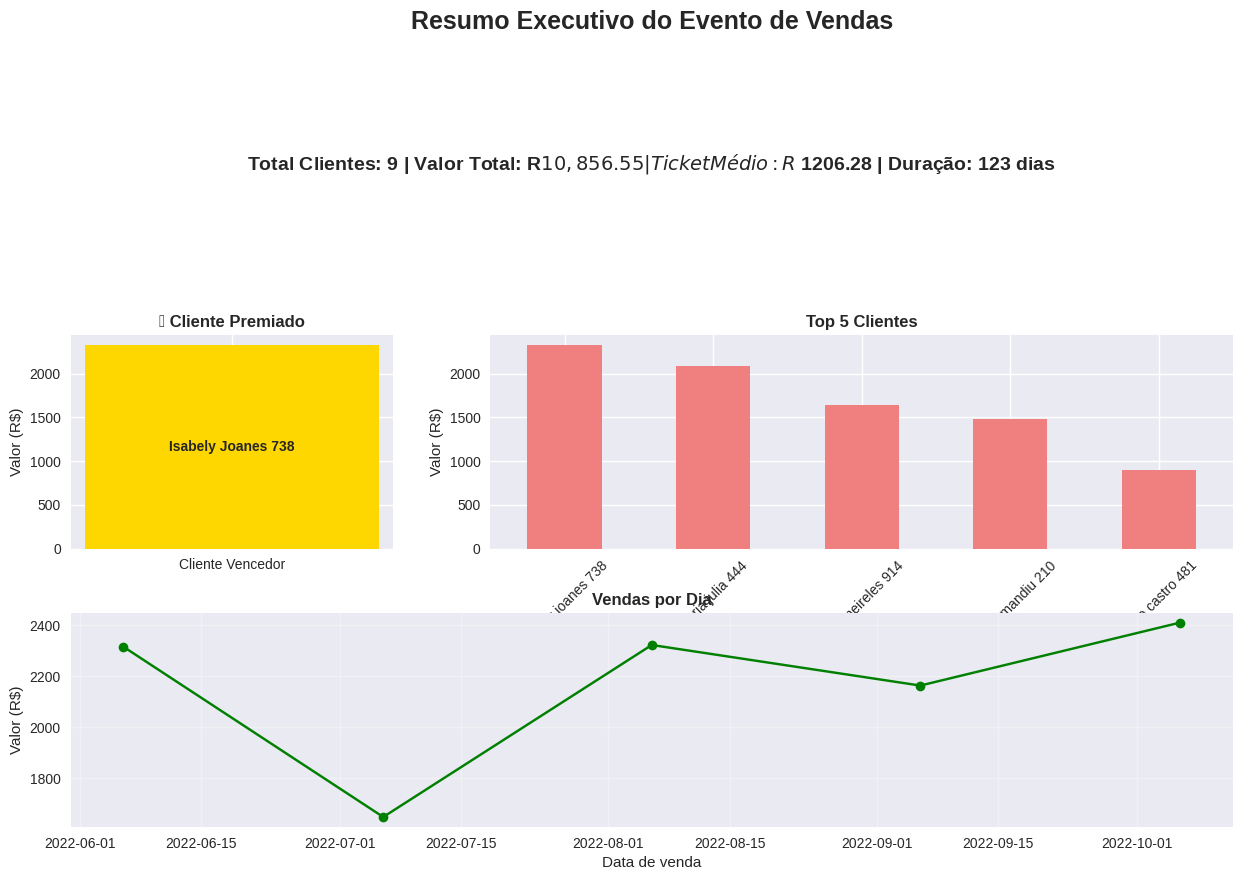

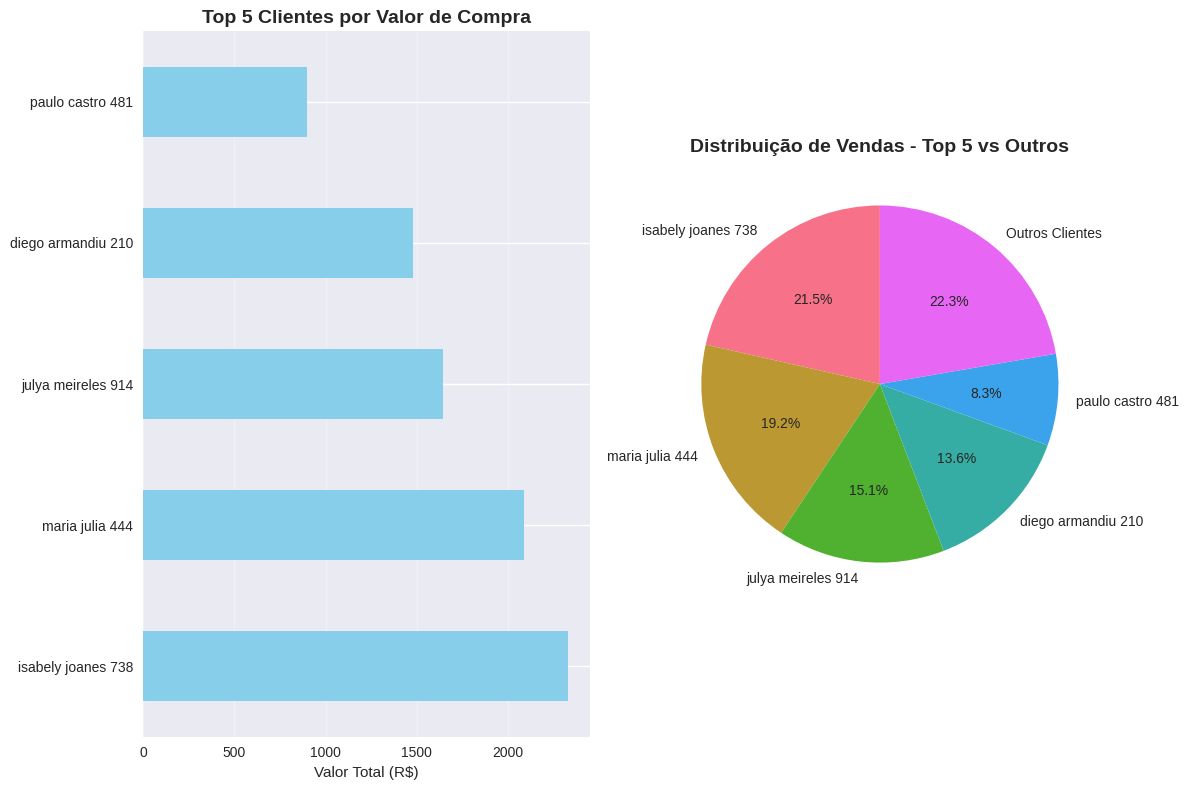

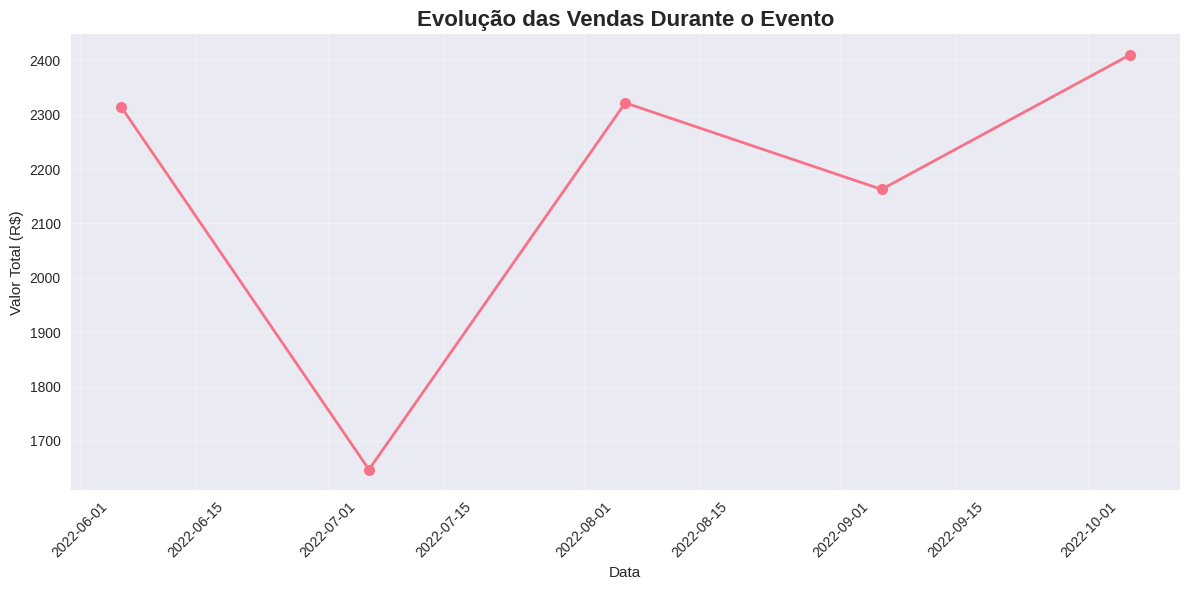

🏠 Gerando visualizações de aluguéis...


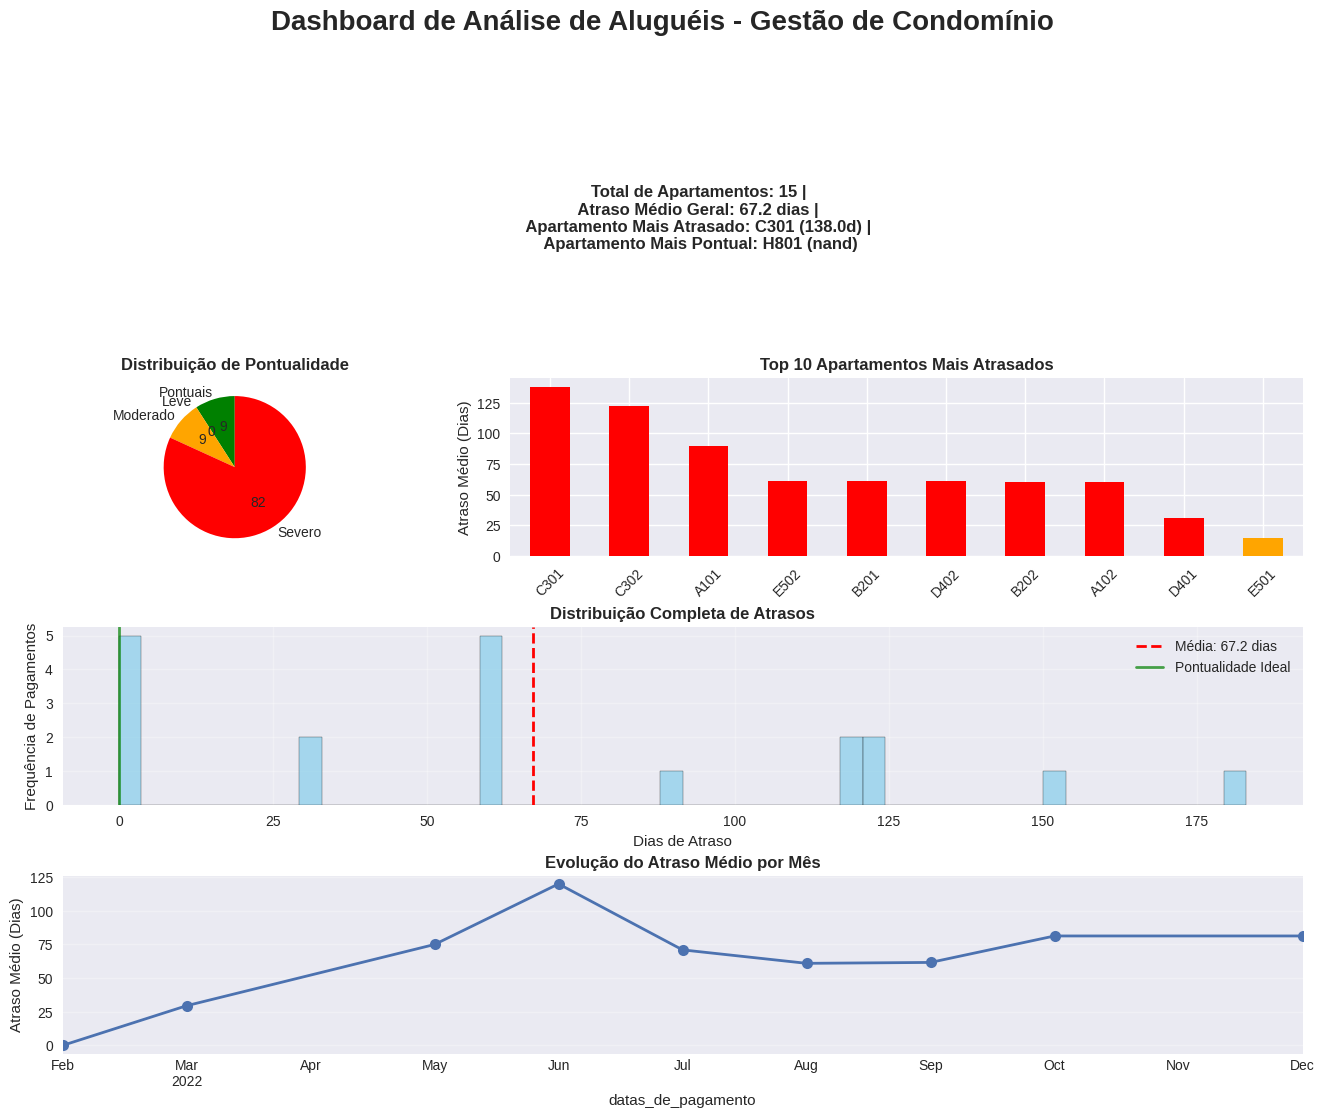

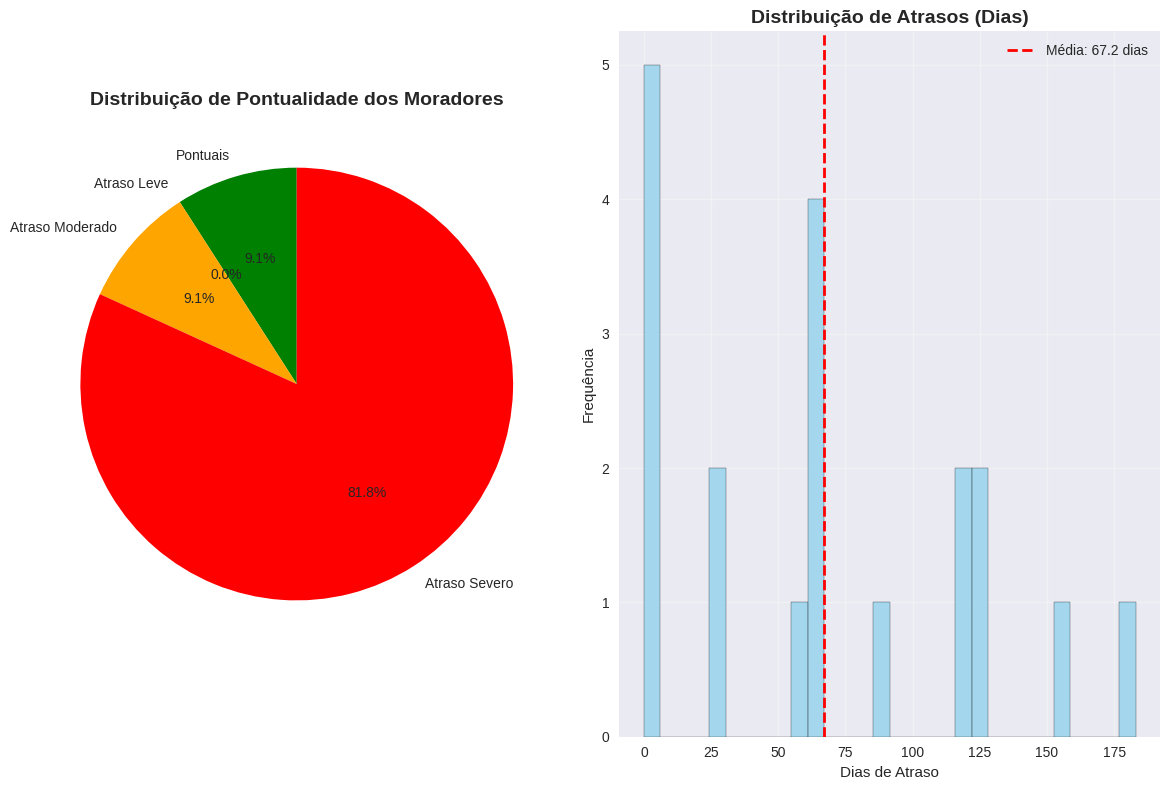

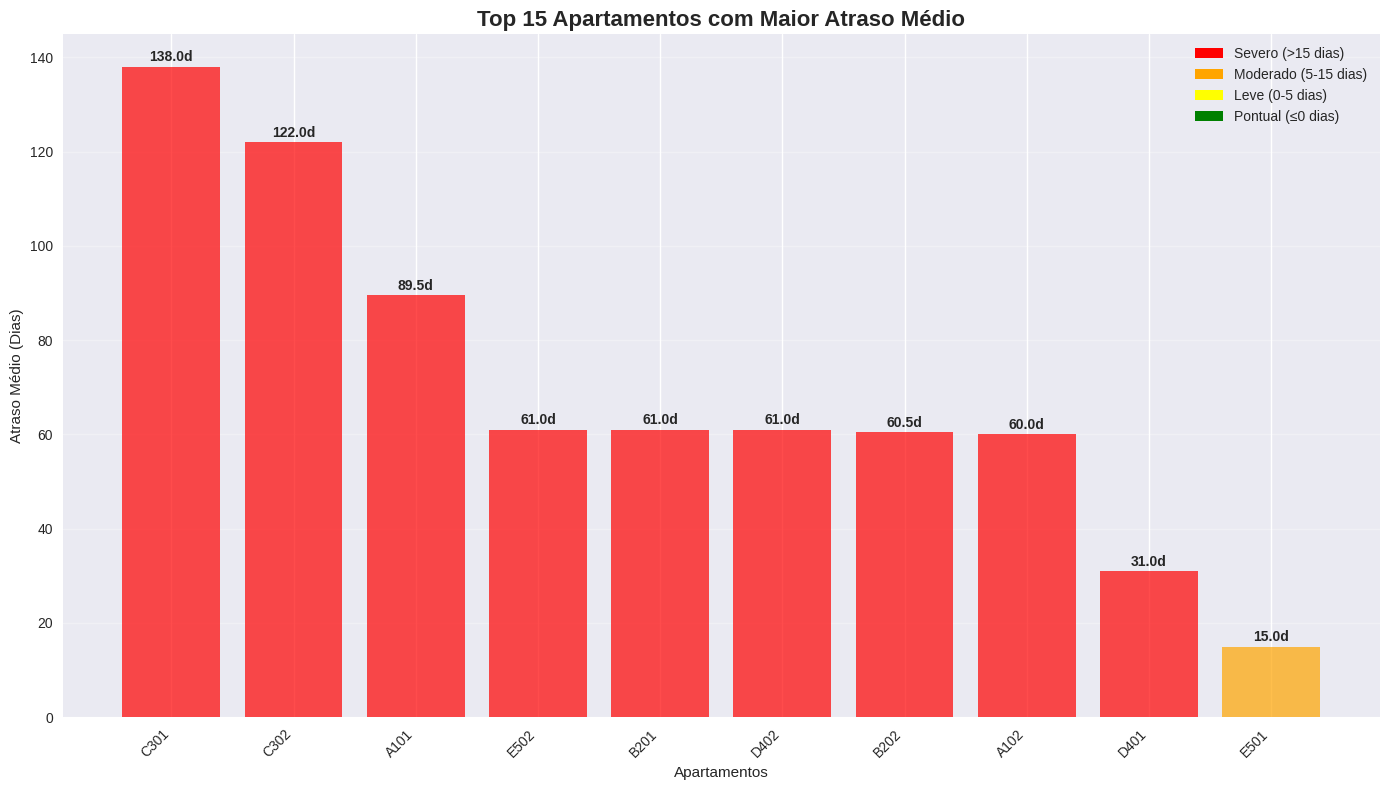


🎯 RELATÓRIO DE VENDAS
Cliente Vencedor: isabely joanes 738
Valor: R$ 2,329.30
Total de Clientes: 9
Valor Total do Evento: R$ 10,856.55

🏠 RELATÓRIO DE ALUGUÉIS
Apartamento Mais Atrasado: C301
Atraso Médio: 138.0 dias
Total de Apartamentos: 15
Atraso Médio Geral: 67.2 dias


In [11]:
# models.py - Modelos de dados com Pydantic
from pydantic import BaseModel, Field, validator
from typing import Optional, List, Dict, Any
from datetime import datetime
import pandas as pd


class DataLoaderConfig(BaseModel):
    """Configuração para carregamento de dados"""
    url: str
    chave: str
    coluna_valor: str
    prefixos_remover: Optional[List[str]] = []

    class Config:
        extra = "allow"


class VendaModel(BaseModel):
    """Modelo para dados de venda"""
    cliente: str = Field(..., min_length=1)
    valor_compra: float = Field(..., gt=0)
    data_venda: datetime

    @validator('cliente')
    def limpar_cliente(cls, v):
        return v.lower().strip()


class LocacaoModel(BaseModel):
    """Modelo para dados de locação"""
    apartamento: str = Field(..., min_length=1)
    valor_aluguel: float = Field(..., gt=0)
    data_combinada_pagamento: datetime
    data_pagamento: datetime

    @validator('apartamento')
    def limpar_apartamento(cls, v):
        return v.replace('(blocoAP)', '').strip()

    @property
    def atraso_dias(self) -> int:
        """Calcula atraso em dias"""
        return (self.data_pagamento - self.data_combinada_pagamento).days


class RelatorioVendas(BaseModel):
    """Modelo para relatório de vendas"""
    cliente_vencedor: str
    valor_vencedor: float
    total_clientes: int
    valor_total_evento: float
    valor_medio_por_cliente: float
    duracao_evento_dias: int
    top_5_clientes: Dict[str, float]
    data_inicio: datetime
    data_fim: datetime


class RelatorioAlugueis(BaseModel):
    """Modelo para relatório de aluguéis"""
    apartamento_mais_atrasado: str
    atraso_maximo_medio: float
    apartamento_mais_pontual: str
    atraso_minimo_medio: float
    total_apartamentos: int
    atraso_medio_geral: float
    distribuicao_pontualidade: Dict[str, int]
    ranking_atrasos: Dict[str, float]


# data_loader.py - Classe para carregamento de dados
import pandas as pd
import numpy as np
from typing import List
import re


class DataLoader:
    """Carregador de dados otimizado com validação Pydantic"""

    def __init__(self):
        self.cache = {}

    def carregar_dados(self, config: DataLoaderConfig) -> pd.DataFrame:
        """Carrega dados usando configuração validada"""
        try:
            # Verifica cache
            if config.url in self.cache:
                return self.cache[config.url].copy()

            # Carrega dados do JSON
            dados_json = pd.read_json(config.url)

            if config.chave not in dados_json:
                raise ValueError(f"Chave '{config.chave}' não encontrada no JSON")

            # Normaliza e processa dados
            dados = pd.json_normalize(dados_json[config.chave])
            dados = self._explodir_colunas_lista(dados)
            dados = self._limpar_valores_monetarios(dados, config.coluna_valor, config.prefixos_remover)

            # Cache dos dados
            self.cache[config.url] = dados.copy()

            return dados

        except Exception as e:
            raise RuntimeError(f"Erro ao carregar dados: {str(e)}")

    def _explodir_colunas_lista(self, df: pd.DataFrame) -> pd.DataFrame:
        """Explode colunas que contêm listas"""
        colunas_para_explodir = df.columns[1:].tolist()
        if colunas_para_explodir:
            return df.explode(colunas_para_explodir).reset_index(drop=True)
        return df

    def _limpar_valores_monetarios(self, df: pd.DataFrame, coluna: str, prefixos: List[str]) -> pd.DataFrame:
        """Limpa e converte valores monetários"""
        if coluna not in df.columns:
            raise KeyError(f"Coluna '{coluna}' não encontrada")

        # Remove prefixos
        for prefixo in prefixos:
            df[coluna] = df[coluna].str.replace(prefixo, '', regex=False)

        # Padroniza formato
        df[coluna] = (df[coluna]
                     .str.replace(',', '.', regex=False)
                     .str.strip())

        # Converte para float
        df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

        return df

    @staticmethod
    def processar_datas(df: pd.DataFrame, colunas_data: List[str]) -> pd.DataFrame:
        """Converte colunas para datetime"""
        df_copy = df.copy()
        for coluna in colunas_data:
            if coluna in df_copy.columns:
                df_copy[coluna] = pd.to_datetime(df_copy[coluna], errors='coerce')
        return df_copy


# analytics.py - Classes de análise
import pandas as pd
from typing import Tuple, Dict


class AnalisadorVendas:
    """Analisador de dados de vendas com Pydantic"""

    def __init__(self, dados_vendas: pd.DataFrame):
        self.dados_vendas = dados_vendas

    def calcular_total_por_cliente(self) -> pd.Series:
        """Calcula total de compras por cliente"""
        return (self.dados_vendas
                .groupby('Cliente')['Valor da compra']
                .sum()
                .sort_values(ascending=False))

    def identificar_cliente_vencedor(self) -> Tuple[str, float]:
        """Identifica cliente com maior compra"""
        total_compras = self.calcular_total_por_cliente()
        return total_compras.index[0], total_compras.iloc[0]

    def gerar_relatorio(self) -> RelatorioVendas:
        """Gera relatório estruturado com Pydantic"""
        total_compras = self.calcular_total_por_cliente()
        cliente_vencedor, valor_vencedor = self.identificar_cliente_vencedor()

        return RelatorioVendas(
            cliente_vencedor=cliente_vencedor,
            valor_vencedor=valor_vencedor,
            total_clientes=len(total_compras),
            valor_total_evento=total_compras.sum(),
            valor_medio_por_cliente=total_compras.mean(),
            duracao_evento_dias=(self.dados_vendas['Data de venda'].max() -
                               self.dados_vendas['Data de venda'].min()).days + 1,
            top_5_clientes=total_compras.head(5).to_dict(),
            data_inicio=self.dados_vendas['Data de venda'].min(),
            data_fim=self.dados_vendas['Data de venda'].max()
        )


class AnalisadorAluguel:
    """Analisador de dados de aluguel com Pydantic"""

    def __init__(self, dados_locacao: pd.DataFrame):
        self.dados_locacao = dados_locacao

    def calcular_atrasos(self) -> pd.DataFrame:
        """Calcula atrasos nos pagamentos"""
        df_copy = self.dados_locacao.copy()
        df_copy['atraso'] = (df_copy['datas_de_pagamento'] -
                            df_copy['datas_combinadas_pagamento']).dt.days
        return df_copy

    def calcular_media_atraso_por_apartamento(self) -> pd.Series:
        """Calcula média de atraso por apartamento"""
        dados_com_atraso = self.calcular_atrasos()
        return (dados_com_atraso
                .groupby('apartamento')['atraso']
                .mean()
                .sort_values(ascending=False))

    def classificar_apartamentos(self) -> Dict[str, List[str]]:
        """Classifica apartamentos por pontualidade"""
        media_atraso = self.calcular_media_atraso_por_apartamento()

        return {
            'pontuais': media_atraso[media_atraso <= 0].index.tolist(),
            'atraso_leve': media_atraso[(media_atraso > 0) & (media_atraso <= 5)].index.tolist(),
            'atraso_moderado': media_atraso[(media_atraso > 5) & (media_atraso <= 15)].index.tolist(),
            'atraso_severo': media_atraso[media_atraso > 15].index.tolist()
        }

    def gerar_relatorio(self) -> RelatorioAlugueis:
        """Gera relatório estruturado com Pydantic"""
        media_atraso = self.calcular_media_atraso_por_apartamento()
        distribuicao = self.classificar_apartamentos()

        return RelatorioAlugueis(
            apartamento_mais_atrasado=media_atraso.index[0],
            atraso_maximo_medio=media_atraso.iloc[0],
            apartamento_mais_pontual=media_atraso.index[-1],
            atraso_minimo_medio=media_atraso.iloc[-1],
            total_apartamentos=len(media_atraso),
            atraso_medio_geral=self.calcular_atrasos()['atraso'].mean(),
            distribuicao_pontualidade={k: len(v) for k, v in distribuicao.items()},
            ranking_atrasos=media_atraso.head(10).to_dict()
        )


# visualizations.py - Visualizações com Matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional
import pandas as pd


class VisualizadorVendas:
    """Visualizações para análise de vendas"""

    def __init__(self, relatorio: RelatorioVendas, dados: pd.DataFrame):
        self.relatorio = relatorio
        self.dados = dados
        plt.style.use('seaborn-v0_8')
        sns.set_palette("husl")

    def plot_top_clientes(self, top_n: int = 10, figsize: tuple = (12, 8)) -> None:
        """Gráfico dos top clientes"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # Gráfico de barras horizontais
        top_clientes = pd.Series(self.relatorio.top_5_clientes)
        top_clientes.plot(kind='barh', ax=ax1, color='skyblue')
        ax1.set_title('Top 5 Clientes por Valor de Compra', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Valor Total (R$)')
        ax1.grid(axis='x', alpha=0.3)

        # Gráfico de pizza - distribuição percentual
        top_5_total = sum(self.relatorio.top_5_clientes.values())
        outros_total = self.relatorio.valor_total_evento - top_5_total

        labels = list(self.relatorio.top_5_clientes.keys()) + ['Outros Clientes']
        sizes = list(self.relatorio.top_5_clientes.values()) + [outros_total]

        ax2.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        ax2.set_title('Distribuição de Vendas - Top 5 vs Outros', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_vendas_por_dia(self, figsize: tuple = (12, 6)) -> None:
        """Gráfico de vendas por dia"""
        vendas_diarias = (self.dados.groupby(self.dados['Data de venda'].dt.date)
                         ['Valor da compra'].sum())

        plt.figure(figsize=figsize)
        vendas_diarias.plot(kind='line', marker='o', linewidth=2, markersize=8)
        plt.title('Evolução das Vendas Durante o Evento', fontsize=16, fontweight='bold')
        plt.xlabel('Data')
        plt.ylabel('Valor Total (R$)')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_estatisticas_resumo(self, figsize: tuple = (15, 10)) -> None:
        """Dashboard completo de vendas"""
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        # Métricas principais
        ax1 = fig.add_subplot(gs[0, :])
        metricas = [
            f'Total Clientes: {self.relatorio.total_clientes}',
            f'Valor Total: R$ {self.relatorio.valor_total_evento:,.2f}',
            f'Ticket Médio: R$ {self.relatorio.valor_medio_por_cliente:.2f}',
            f'Duração: {self.relatorio.duracao_evento_dias} dias'
        ]

        ax1.text(0.5, 0.5, ' | '.join(metricas), ha='center', va='center',
                fontsize=14, fontweight='bold', transform=ax1.transAxes)
        ax1.axis('off')
        ax1.set_title('Resumo Executivo do Evento de Vendas', fontsize=18, fontweight='bold', pad=20)

        # Destaque do cliente vencedor
        ax2 = fig.add_subplot(gs[1, 0])
        ax2.bar(['Cliente Vencedor'], [self.relatorio.valor_vencedor], color='gold', width=0.5)
        ax2.set_title('🏆 Cliente Premiado', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Valor (R$)')
        ax2.text(0, self.relatorio.valor_vencedor/2, self.relatorio.cliente_vencedor.title(),
                ha='center', va='center', fontweight='bold')

        # Top 5 clientes
        ax3 = fig.add_subplot(gs[1, 1:])
        top_5 = pd.Series(self.relatorio.top_5_clientes)
        top_5.plot(kind='bar', ax=ax3, color='lightcoral')
        ax3.set_title('Top 5 Clientes', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Valor (R$)')
        ax3.tick_params(axis='x', rotation=45)

        # Vendas por dia
        ax4 = fig.add_subplot(gs[2, :])
        vendas_diarias = (self.dados.groupby(self.dados['Data de venda'].dt.date)
                         ['Valor da compra'].sum())
        vendas_diarias.plot(kind='line', ax=ax4, marker='o', color='green')
        ax4.set_title('Vendas por Dia', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Valor (R$)')
        ax4.grid(True, alpha=0.3)

        plt.show()


class VisualizadorAlugueis:
    """Visualizações para análise de aluguéis"""

    def __init__(self, relatorio: RelatorioAlugueis, dados: pd.DataFrame):
        self.relatorio = relatorio
        self.dados = dados
        plt.style.use('seaborn-v0_8')

    def plot_distribuicao_atrasos(self, figsize: tuple = (12, 8)) -> None:
        """Gráfico da distribuição de atrasos"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # Gráfico de pizza - categorias de atraso
        labels = ['Pontuais', 'Atraso Leve', 'Atraso Moderado', 'Atraso Severo']
        sizes = [self.relatorio.distribuicao_pontualidade[k] for k in
                ['pontuais', 'atraso_leve', 'atraso_moderado', 'atraso_severo']]
        colors = ['green', 'yellow', 'orange', 'red']

        ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        ax1.set_title('Distribuição de Pontualidade dos Moradores', fontsize=14, fontweight='bold')

        # Histograma de atrasos
        atrasos = (self.dados['datas_de_pagamento'] - self.dados['datas_combinadas_pagamento']).dt.days
        ax2.hist(atrasos, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        ax2.axvline(atrasos.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Média: {atrasos.mean():.1f} dias')
        ax2.set_title('Distribuição de Atrasos (Dias)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Dias de Atraso')
        ax2.set_ylabel('Frequência')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_ranking_apartamentos(self, top_n: int = 15, figsize: tuple = (14, 8)) -> None:
        """Gráfico do ranking de apartamentos mais atrasados"""
        ranking = pd.Series(self.relatorio.ranking_atrasos).head(top_n)

        fig, ax = plt.subplots(figsize=figsize)

        # Define cores baseadas no nível de atraso
        colors = []
        for atraso in ranking.values:
            if atraso > 15:
                colors.append('red')
            elif atraso > 5:
                colors.append('orange')
            elif atraso > 0:
                colors.append('yellow')
            else:
                colors.append('green')

        bars = ax.bar(range(len(ranking)), ranking.values, color=colors, alpha=0.7)

        # Adiciona valores nas barras
        for i, (apt, atraso) in enumerate(ranking.items()):
            ax.text(i, atraso + 0.5, f'{atraso:.1f}d', ha='center', va='bottom', fontweight='bold')

        ax.set_title(f'Top {top_n} Apartamentos com Maior Atraso Médio', fontsize=16, fontweight='bold')
        ax.set_xlabel('Apartamentos')
        ax.set_ylabel('Atraso Médio (Dias)')
        ax.set_xticks(range(len(ranking)))
        ax.set_xticklabels(ranking.index, rotation=45, ha='right')

        # Legenda de cores
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='red', label='Severo (>15 dias)'),
            Patch(facecolor='orange', label='Moderado (5-15 dias)'),
            Patch(facecolor='yellow', label='Leve (0-5 dias)'),
            Patch(facecolor='green', label='Pontual (≤0 dias)')
        ]
        ax.legend(handles=legend_elements, loc='upper right')

        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    def plot_dashboard_alugueis(self, figsize: tuple = (16, 12)) -> None:
        """Dashboard completo de aluguéis"""
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

        # Título principal
        fig.suptitle('Dashboard de Análise de Aluguéis - Gestão de Condomínio',
                    fontsize=20, fontweight='bold', y=0.98)

        # Métricas principais
        ax1 = fig.add_subplot(gs[0, :])
        metricas_text = f"""
        Total de Apartamentos: {self.relatorio.total_apartamentos} |
        Atraso Médio Geral: {self.relatorio.atraso_medio_geral:.1f} dias |
        Apartamento Mais Atrasado: {self.relatorio.apartamento_mais_atrasado} ({self.relatorio.atraso_maximo_medio:.1f}d) |
        Apartamento Mais Pontual: {self.relatorio.apartamento_mais_pontual} ({self.relatorio.atraso_minimo_medio:.1f}d)
        """
        ax1.text(0.5, 0.5, metricas_text, ha='center', va='center', fontsize=12,
                fontweight='bold', transform=ax1.transAxes)
        ax1.axis('off')

        # Distribuição de pontualidade (pizza)
        ax2 = fig.add_subplot(gs[1, 0])
        labels = ['Pontuais', 'Leve', 'Moderado', 'Severo']
        sizes = [self.relatorio.distribuicao_pontualidade[k] for k in
                ['pontuais', 'atraso_leve', 'atraso_moderado', 'atraso_severo']]
        colors = ['green', 'yellow', 'orange', 'red']
        ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.0f', startangle=90)
        ax2.set_title('Distribuição de Pontualidade', fontsize=12, fontweight='bold')

        # Top 10 apartamentos mais atrasados
        ax3 = fig.add_subplot(gs[1, 1:])
        top_10 = pd.Series(self.relatorio.ranking_atrasos).head(10)
        colors_bar = ['red' if x > 15 else 'orange' if x > 5 else 'yellow' if x > 0 else 'green'
                     for x in top_10.values]
        top_10.plot(kind='bar', ax=ax3, color=colors_bar)
        ax3.set_title('Top 10 Apartamentos Mais Atrasados', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Atraso Médio (Dias)')
        ax3.tick_params(axis='x', rotation=45)

        # Histograma de todos os atrasos
        ax4 = fig.add_subplot(gs[2, :])
        atrasos = (self.dados['datas_de_pagamento'] - self.dados['datas_combinadas_pagamento']).dt.days
        ax4.hist(atrasos, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        ax4.axvline(atrasos.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Média: {atrasos.mean():.1f} dias')
        ax4.axvline(0, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Pontualidade Ideal')
        ax4.set_title('Distribuição Completa de Atrasos', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Dias de Atraso')
        ax4.set_ylabel('Frequência de Pagamentos')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # Análise temporal (se houver dados suficientes)
        ax5 = fig.add_subplot(gs[3, :])
        if 'datas_de_pagamento' in self.dados.columns:
            atrasos_mensais = (self.dados.groupby(self.dados['datas_de_pagamento'].dt.to_period('M'))
                              .apply(lambda x: ((x['datas_de_pagamento'] - x['datas_combinadas_pagamento'])
                                               .dt.days.mean())))
            if len(atrasos_mensais) > 1:
                atrasos_mensais.plot(kind='line', ax=ax5, marker='o', linewidth=2, markersize=8)
                ax5.set_title('Evolução do Atraso Médio por Mês', fontsize=12, fontweight='bold')
                ax5.set_ylabel('Atraso Médio (Dias)')
                ax5.grid(True, alpha=0.3)
            else:
                ax5.text(0.5, 0.5, 'Dados insuficientes para análise temporal',
                        ha='center', va='center', transform=ax5.transAxes)
                ax5.axis('off')

        plt.show()


# main.py - Arquivo principal refatorado
def main():
    """Função principal modular"""

    # Configurações
    configs = {
        'vendas': DataLoaderConfig(
            url="https://raw.githubusercontent.com/YuriArduino/Estudos_Pandas/refs/heads/data-tests/dados_vendas_clientes.json",
            chave='dados_vendas',
            coluna_valor='Valor da compra',
            prefixos_remover=['R$ ']
        ),
        'locacao': DataLoaderConfig(
            url="https://raw.githubusercontent.com/YuriArduino/Estudos_Pandas/refs/heads/data-tests/dados_locacao_imoveis.json",
            chave='dados_locacao',
            coluna_valor='valor_aluguel',
            prefixos_remover=['$', ' reais']
        )
    }

    try:
        # Carregamento de dados
        loader = DataLoader()

        # Dados de vendas
        dados_vendas = loader.carregar_dados(configs['vendas'])
        dados_vendas['Cliente'] = dados_vendas['Cliente'].str.lower().str.strip()
        dados_vendas = loader.processar_datas(dados_vendas, ['Data de venda'])

        # Dados de locação
        dados_locacao = loader.carregar_dados(configs['locacao'])
        dados_locacao['apartamento'] = dados_locacao['apartamento'].str.replace('(blocoAP)', '').str.strip()
        dados_locacao = loader.processar_datas(dados_locacao,
                                             ['datas_combinadas_pagamento', 'datas_de_pagamento'])

        # Análises
        analisador_vendas = AnalisadorVendas(dados_vendas)
        relatorio_vendas = analisador_vendas.gerar_relatorio()

        analisador_aluguel = AnalisadorAluguel(dados_locacao)
        relatorio_alugueis = analisador_aluguel.gerar_relatorio()

        # Visualizações
        print("🎯 Gerando visualizações de vendas...")
        viz_vendas = VisualizadorVendas(relatorio_vendas, dados_vendas)
        viz_vendas.plot_estatisticas_resumo()
        viz_vendas.plot_top_clientes()
        viz_vendas.plot_vendas_por_dia()

        print("🏠 Gerando visualizações de aluguéis...")
        viz_alugueis = VisualizadorAlugueis(relatorio_alugueis, dados_locacao)
        viz_alugueis.plot_dashboard_alugueis()
        viz_alugueis.plot_distribuicao_atrasos()
        viz_alugueis.plot_ranking_apartamentos()

        # Relatórios estruturados
        print("\n" + "="*60)
        print("🎯 RELATÓRIO DE VENDAS")
        print("="*60)
        print(f"Cliente Vencedor: {relatorio_vendas.cliente_vencedor}")
        print(f"Valor: R$ {relatorio_vendas.valor_vencedor:,.2f}")
        print(f"Total de Clientes: {relatorio_vendas.total_clientes}")
        print(f"Valor Total do Evento: R$ {relatorio_vendas.valor_total_evento:,.2f}")

        print("\n" + "="*60)
        print("🏠 RELATÓRIO DE ALUGUÉIS")
        print("="*60)
        print(f"Apartamento Mais Atrasado: {relatorio_alugueis.apartamento_mais_atrasado}")
        print(f"Atraso Médio: {relatorio_alugueis.atraso_maximo_medio:.1f} dias")
        print(f"Total de Apartamentos: {relatorio_alugueis.total_apartamentos}")
        print(f"Atraso Médio Geral: {relatorio_alugueis.atraso_medio_geral:.1f} dias")

    except Exception as e:
        print(f"❌ Erro: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()